<h1 align="center"> pyeCE tutorial </h1>
<h3 align="center">Yann Lorris Mueller and Anirudh Raju Natarajan</h3>


<center><img src="Figures/pyece_logo.png" height="200px"></center>

In [1]:
# Load parser libraries
import yaml
import json
import pandas as pd

# Load libraries to perform mathematical tasks
import numpy as np
from scipy.spatial import ConvexHull, convex_hull_plot_2d
from scipy.integrate import cumulative_simpson

# Load pymatgen functionalities to deal with crystal structures
from pymatgen.core import Structure

# Load pyece functionalities
from pyece.core.clex import eCE
from pyece.learn.data import ConfigData, DataBase, ClexDataset

# Load pyplot
import matplotlib.pyplot as plt
    

## 1) Construct an eCE model

### a) Set up the primitive structure

The **embedded cluster expansion** (eCE) is an **on-lattice** atomistic model. Atoms are assumed to sit on lattice sites. The model only deals with the configurational degree of freedom.
Hence, as a first step, one should determine the crystal structure, as well as the species allowed to sit on each lattice site. 

In **pyeCE**, the system is defined by a PRIM file, similar to a VASP POSCAR file, with the permitted spieces indicated for each atomic site.
To create the PRIM file, one needs to determine:
* **The lattice**: 3 linearly-independent vectors that define the primitive cell
* **The basis sites**: N 3-D vectors indicating the positions of the atoms within the primitive cell
* **The degree of freedom**: permitted species for each atomic site

<img src="Figures/prim.png" height="300px">

<h2 align="center">Example</h2>

In this example, we will construct the PRIM object that determines the primitive cell and the chemical degrees of freedom. The system consists of a FCC lattice, in which lattice sites can be occupied by elements of group 11 (Cu, Ag, and Au).

We use the ``Structure`` class in Pymatgen to perform this task.

In [2]:
# Parameters
species = ['Ag', 'Au', 'Cu']
a = 3.5727932
fcc_lattice = [
    [a/2, a/2,   0],
    [  0, a/2, a/2],
    [a/2, a/2,   0]
]
coords = [[0.0, 0.0, 0.0]]

# Create POSCAR file
elem = 'Ag'
primitive = Structure(
    lattice = fcc_lattice,
    species = [elem]*len(coords), 
    coords  = coords
)
prim_file = primitive.to(fmt='poscar').split('\n')

# Create pyece PRIM file
prim_file[0] = ' '.join(species)
prim_file.pop(5)
for index in range(7, len(prim_file)):
    prim_file[index] = prim_file[index].replace(elem, ' '.join(species))

# Save pyece PRIM file
with open('PRIM_FCC.vasp', 'w') as f:
    f.write('\n'.join(prim_file))
print(*prim_file,sep='\n')

Ag Au Cu
1.0
   1.7863966000000000    1.7863966000000000    0.0000000000000000
   0.0000000000000000    1.7863966000000000    1.7863966000000000
   1.7863966000000000    1.7863966000000000    0.0000000000000000
1
direct
   0.0000000000000000    0.0000000000000000    0.0000000000000000 Ag Au Cu



<h2 align="center">Task</h2>

Create the prim file of a BCC primitive structure where atomic sites can be occupied by the 6 species of the groups 5 and 6, namely Cr, Mo, Nb, Ta, V, and W, with a lattice parameter $a=3.5727932$.

In [5]:
# Parameters
species = ['Cr', 'Mo', 'Nb', 'Ta', 'V', 'W']
a = 3.5727932
bcc_lattice = [
    [-a/2, -a/2,  a/2],
    [-a/2,  a/2, -a/2],
    [ a/2, -a/2, -a/2]
]
coords = [[0.0, 0.0, 0.0]]

# Create POSCAR file
elem = 'Cr'
primitive = Structure(
    lattice = bcc_lattice,
    species = [elem]*len(coords), 
    coords  = coords
)
prim_file = primitive.to(fmt='poscar').split('\n')

# Create pyece PRIM file
prim_file[0] = ' '.join(species)
prim_file.pop(5)
for index in range(7, len(prim_file)):
    prim_file[index] = prim_file[index].replace(elem, ' '.join(species))

# Save pyece PRIM file
with open('PRIM_BCC.vasp', 'w') as f:
    f.write('\n'.join(prim_file))
print(*prim_file,sep='\n')

Cr Mo Nb Ta V W
1.0
  -1.7863966000000000   -1.7863966000000000    1.7863966000000000
  -1.7863966000000000    1.7863966000000000   -1.7863966000000000
   1.7863966000000000   -1.7863966000000000   -1.7863966000000000
1
direct
   0.0000000000000000    0.0000000000000000    0.0000000000000000 Cr Mo Nb Ta V W



### b) Set up the settings to build the eCE model

Once the system is defined, one needs to determine how atoms interact with each other, i.e., the Hamiltonian of the system. Cluster expansions act as highly efficient surrogate models that evaluate the energy of on-lattice atomic arrangement. **pyeCE** models require to specify: 
* **Types of interactions**: to build an eCE model, one needs to specify the type of interactions. One typically considers all pair interactions within a given a sphere of radius $r_{pair}$, all triplet interactions within a given a sphere of radius $r_{triplet}$, etc...
* **Site-basis functions**: one also needs to define the map between the occupational elements and vectors spanning the $k$-dimensional space $\mathbb{R}^k$. To do so, one need to specify the kind of basis vectors, e.g., Chebyshev or occupational, and the number of dimension $k$. In traditional cluster expansion, k is equal to the number of elements. Within the embedded cluster expansion framework, this number is smaller, and species are projected to a lower-dimensional space.
* **Neural network**: specifically to the embedded cluster expansion framework, the descriptors are used as input of a neural network that evaluates the energy of the structure. The neural network typically consists of a simple feedforward network.

<img src="Figures/build.png" height="400px">

**EXAMPLE**

In this example, we will create an eCE model with pair interactions up to a radius $r_{pair} = 6.0\AA$, $r_{triplet} = 4.5\AA$, and $r_{quadruplet} = 4.0\AA$ with a Chebyshev basis, for the FCC ternary system described in the example above. The number of dimensions is reduced to 2 ($k=2$). Use a feed-forward neural network composed of 2 layers with 128 and 64 nodes for each layer, respectively, and ReLU activation functions between each layer.

We use the CLI command ``ece build`` to perform this task.

In [57]:
# Parameters
path_to_PRIM = 'PRIM_FCC.vasp'
radii = [0.0, 0.0, 6.0, 4.5, 4.0]
basis = 'chebyshev'
k = 2
nn_layers = [128, 64]
activation = 'ReLU'
model_name = 'model_FCC.pth'

# Create settings file
orbit_tree_specs = {
    "orbit_tree_length_filter": {str(body_order): {'max_length': radius} for body_order, radius in enumerate(radii)}
}
settings = {
    # Prim specifications
    "prim" : path_to_PRIM,
    "basis": basis,
    "orbit_tree_specs": orbit_tree_specs,

    # ECI neural network specifications
    "embedding_dimensions": [k],
    "nn_layers": nn_layers,
    "activation": activation,
    
    # Model
    "name": model_name,
}
with open('build_settings.yaml', 'w') as f:
    yaml.dump(settings, f, default_flow_style=False)
    
# Build the eCE model using the built-in CLI function
! ece build -s build_settings.yaml


You can print information about the ``Prim``, ``SiteBasis``, and ``Features`` of the eCE model using the CLI command ``ece print`` with the ``p`` flag for the Prim, the ``s`` flag for the Sitebasis, and the ``f`` flag for the Features.

In [ ]:
! ece print --model model_BCC.pth -p



                           PRIM                            
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ General:                                                ┃
┃ --------                                                ┃
┃ Space group        :   Im-3m (229)                      ┃
┃ Chemical species   :   Cr  Mo  Nb  Ta  V  W             ┃
┃ Chemical indexes        0   1   2   3  4  5             ┃
┃ Symmetries         :   48 operations                    ┃
┃ Accuracy           :   6 digits                         ┃
┃ Cutoff             :   8.0 Å                            ┃
┃ neighborhood size  :   113 atomic sites                 ┃
┣━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┫
┃ Lattice:                                                ┃
┃ --------                                                ┃
┃ a           -1.7864  -1.7864   1.7864                   ┃
┃ b           -1.7864   1.7864  -1.7864                   ┃
┃ c            1.7864  -1.7864  -1.786

## 2) Train the eCE model

### a) Construct a training database

eCE models need to be trained on data. These data typically consist of symmetrically unique orderings/arrangements of atoms in small supercells of the primitive structure.

<img src="Figures/data.png" height="600px">

The construction of such a database is typically performed using the enumeration algorithm developed by Gus Hart. The EnumerateStructureTransformation function in Pymatgen implements the algorithm. We then compute the energy of the structures using DFT.

The ``database.pkl`` file is a collection of more than 3600 data for the BCC senary system composed of Cr, Mo, Nb, Ta, V, and W. The database is composed of the elements as follows:
* **The composition**: The composition of each data is given by the columns named as `x_ELEM`
* **The property of interest**: The column ``property`` here refers to the formation energy per atom
* **The ordering**: The column ``ConfigData`` consists of the input object that describe the specific ordering/arrangement of atoms

In a first step, we usually analyse the system by plotting binary **convex hulls**. Convex hulls are similar to phase diagrams at 0K. They show the ground states and common tangent constructions.

The command below prints the data contained in the database.

! ece print --model model_BCC.pth -d Files/database.pkl

**TASK**

Plot the convex hull of the Mo-Ta binary system.

You can use the ``ConvexHull`` and ``convex_hull_plot_2d`` functionalities from scipy to compute the convex hull and plot it, respectively.

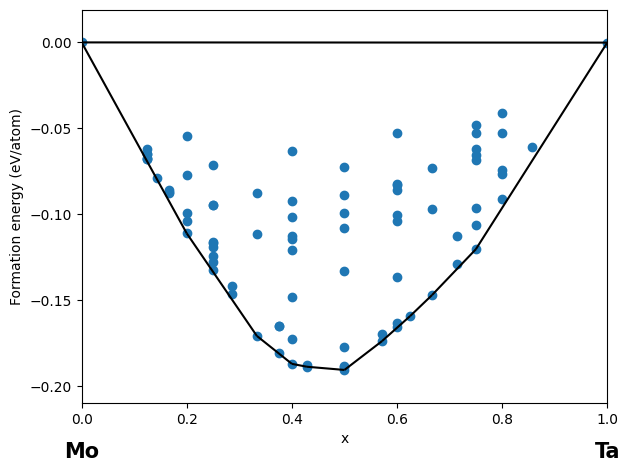

In [6]:
db = DataBase.from_pickle('Files/database.pkl')
elements = ['Mo', 'Ta']

# Select the binary data
db = db[(db[['x_%s'%elem for elem in elements]].sum(axis=1)-1.0).abs()< 1e-6]

# Construct convex hull
data = db[['x_%s'%elements[1], 'property']].to_numpy()
hull = ConvexHull(data)

fig, ax = plt.subplots()
convex_hull_plot_2d(hull=hull, ax=ax)
plt.axis([0, 1, None, None])
plt.annotate(elements[0], xy=(0, -0.1), xycoords='axes fraction', ha='center', va='top', fontsize=15, fontweight='bold')
plt.annotate(elements[1], xy=(1, -0.1), xycoords='axes fraction', ha='center', va='top', fontsize=15, fontweight='bold')
plt.xlabel('x')
plt.ylabel('Formation energy (eV/atom)')
plt.tight_layout()
plt.show()


 ### b) Fit the eCE model

Now that we have a model and a training database, we can train the model. This task is performed by using advanced gradient descent techniques as implemented in pyTorch. So-called ladder training is carried out to help remain in the global minimum (There is no proof that the minimum achieved with this technique is the global minimum, but it has been observed that it yields much better results than without ladder training.). Ladder training consists in performing several subsequent training, starting with a few descriptors (typically first- and second-nearest neighbor pair interactions), and slowely increasing the number of descriptors (typically by increasing the radius of interactions) up to the final training with all descriptors.

The figure below shows a 3-steps ladder training. In the first step, first- and second-nearest neighbor pairs are considered. Then the third- and fourth-nearest neighbor pairs are added. And finally, the triplets are added as well.

<img src="Figures/ladder_training_illustration.png" height="300px">

The main settings for training are:
* **train_prop**: the proportion of data within the database used for the training dataset.
* **valid_prop**: the proportion of data within the database used for the validation dataset.
* **test_prop**: the proportion of data within the database used for the testing dataset.
* **batch_size**: the number of data to include within each batch.
* **loss_fct**: the name of loss function to be used, as available in pyTorch (typically use MSELoss).
* **ladder_steps**: it is a list which indicated the number of first orbits (as indicated when printing the ``Features`` using ``ece print --model model_BCC.pth -f``) to include at each ladder step
* **optimizers**: the name of the optimizer, as available in pyTorch (typically use Adam), to be used at each ladder step. The specific options related to the optimizer are indicated as a dictionary.
* **epochs**: the number of epochs to be carried out at each ladder step.
* **lr**: the learning rate to be used at each ladder step.
* **schedulers**: the name of the schedulers, as available in pyTorch (typically use MultiStepLR), to be used at each ladder step. The specific options related to the scheduler are indicated as a dictionary.
* **earlystopping_patience**: the number of epochs where the validation error is not decreasing to be performed before we stop, for each ladder step.

**TASK**

Train the eCe model for the senary BCC system. The script below construct the fittng settings and carry out the training process. The training settings are as follows:
* **train_prop**:             60%
* **valid_prop**:             10%
* **test_prop**:              30%
* **batch_size**:             50 data
* **loss_fct**:               MSELoss (mean square error loss function in pyTorch)
* **ladder_steps**:           [11] (only one ladder step where all orbits are considered)
* **optimizers**:             Adam, using the amsgrad functionality
* **epochs**:                 [100] (100 minimization steps)
* **lr**:                     [1e-3] (the starting learning rate is set to 1e-3)
* **schedulers**:             MultiStepLR, with gamma set to 0.1 and milestones set to [50, 80] (the learning rate is mulitplied by 0.1 at each milestone, here when the number of steps reaches 50 and 80)
* **earlystopping_patience**: [10] (if the validation loss function does not descreses during 10 steps in a row, the algorithm stops to prevent overfitting)
These settings yield a poor fit. The task is to modify these settings to achieve a fit with a MSE loss below 0.0001. 


We use the CLI command ``ece fit`` to perform this task.

In [8]:
# Parameters
database_name = 'Files/database.pkl'
model_name = 'Files/model_BCC.pth'
training_proportion = 0.6
validation_proportion = 0.1
testing_proportion = 0.3
batch_size = 50
loss_fct = 'MSELoss'
ladder_steps = [11]
optimizer_name = 'Adam'
list_optimizers = [{optimizer_name: {'amsgrad': True}} for step in range(len(ladder_steps))]
scheduler_name = 'MultiStepLR'
list_schedulers = [{scheduler_name: {'milestones': [50, 80], 'gamma': 0.1}}]
epochs = [100]
lr = [1e-3]
earlystopping_patience = [10]
device = 'cpu'

# Training settings
settings = {
    # Database specifications
    'data_file': database_name,
    'train_prop': training_proportion,
    'valid_prop': validation_proportion,
    'test_prop': [testing_proportion],

    # Gradient descent specification
    'ladder_steps': ladder_steps,
    'epochs': epochs,
    'lr': lr,
    'optimizers': list_optimizers,
    'schedulers': list_schedulers,
    'earlystopping_patience': earlystopping_patience,
    'loss_fct': loss_fct,
    'batch_size': batch_size,
    
    # Model
    'model': model_name,
    "name": model_name,
    'device': device,
    
    # Verbosity
    'verbose': True
}
with open('train_settings.yaml', 'w') as f:
    yaml.dump(settings, f, default_flow_style=False)

# Build the eCE model using the built-in CLI function
! ece fit -s train_settings.yaml

eCE(
  (sitebasis): SiteBasis(
    (constant_padding): ConstantPad2d(padding=(0, 0, 1, 0), value=1)
    (projection_matrices): ModuleList(
      (0): Sequential(
        (0): Linear(in_features=5, out_features=2, bias=False)
        (1): ConstantPad2d(padding=(0, 0, 0, 0), value=inf)
      )
    )
  )
  (features): Features()
  (eci): Sequential(
    (0): Linear(in_features=33, out_features=128, bias=False)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=1, bias=True)
  )
)

Random Data Splitting:
The training dataset contains 2168 data
The validation dataset contains 361 data
The test dataset 0 contains 1085 data


Entering ladder training step 0
-------------------------------
Included orbits:
   - Orbit_0_0
   - Orbit_1_0
   - Orbit_2_0
   - Orbit_2_1
   - Orbit_2_2
   - Orbit_2_3
   - Orbit_2_4
   - Orbit_2_5
   - Orbi

In [9]:
# Parameters
database_name = 'Files/database.pkl'
model_name = 'Files/model_BCC.pth'
training_proportion = 0.6
validation_proportion = 0.1
testing_proportion = 0.3
batch_size = 50
loss_fct = 'MSELoss'
ladder_steps = [4, 6, 8, 10, 11]
optimizer_name = 'Adam'
list_optimizers = [{optimizer_name: {'amsgrad': True}} for step in range(len(ladder_steps))]
scheduler_name = 'MultiStepLR'
list_schedulers = [{scheduler_name: {'milestones': [15, 35] if step > 0 else [55, 85, 95], 'gamma': 0.1}} for step in range(len(ladder_steps))]
epochs = [100, 40, 40, 40, 40]
lr = [1e-3 if step > 0 else 1e-2 for step in range(len(ladder_steps))]
earlystopping_patience = [100, 40, 40, 40, 40]
device = 'cpu'

# Training settings
settings = {
    # Database specifications
    'data_file': database_name,
    'train_prop': training_proportion,
    'valid_prop': validation_proportion,
    'test_prop': [testing_proportion],

    # Gradient descent specification
    'ladder_steps': ladder_steps,
    'epochs': epochs,
    'lr': lr,
    'optimizers': list_optimizers,
    'schedulers': list_schedulers,
    'earlystopping_patience': earlystopping_patience,
    'loss_fct': loss_fct,
    'batch_size': batch_size,
    
    # Model
    'model': model_name,
    "name": model_name,
    'device': device,
    
    # Verbosity
    'verbose': True
}
with open('train_settings.yaml', 'w') as f:
    yaml.dump(settings, f, default_flow_style=False)

# Build the eCE model using the built-in CLI function
! ece fit -s train_settings.yaml

eCE(
  (sitebasis): SiteBasis(
    (constant_padding): ConstantPad2d(padding=(0, 0, 1, 0), value=1)
    (projection_matrices): ModuleList(
      (0): Sequential(
        (0): Linear(in_features=5, out_features=2, bias=False)
        (1): ConstantPad2d(padding=(0, 0, 0, 0), value=inf)
      )
    )
  )
  (features): Features()
  (eci): Sequential(
    (0): Linear(in_features=33, out_features=128, bias=False)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=1, bias=True)
  )
)

Random Data Splitting:
The training dataset contains 2168 data
The validation dataset contains 361 data
The test dataset 0 contains 1085 data


Entering ladder training step 0
-------------------------------
Included orbits:
   - Orbit_0_0
   - Orbit_1_0
   - Orbit_2_0
   - Orbit_2_1

Epoch 0
Learning rate   1.00e-02   1.00e-02
Validation loss decrease

### c) Compare convex hulls

Once the eCE model is trained, one needs to assess its correctness. In materials science, we are typically interested in correctly reproduce ground states. Comparing the convex hull obtained with DFT and with the model is an efficient way of assessing the accuracy of a model.

**TASK**

Plot the convex hull of the Mo-Ta binary system for formation energies obtained with DFT and with the trained model.

You can use the ``ConvexHull`` and ``convex_hull_plot_2d`` functionalities from scipy to compute the convex hull and plot it, respectively.
You can use the following pyeCE functionalities to evaluate the energy of a structure:
* ``eCE.load(path_to_model)`` to load the model
* ``ConfigData.from_dict(dict)`` to load the configuration, where dict correcponds to the values in the ``ConfigData`` column in the database
* ``ClexDataset.build_dataset(configdata)`` to create inputs for the model
* ``model(X.neighborhood_occupations).mean()`` to evaluate the averaged formation energy of the configuration data

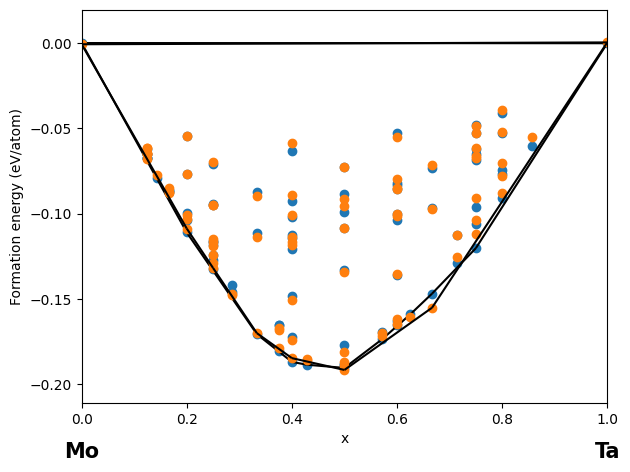

In [13]:
db = DataBase.from_pickle('Files/database.pkl')
model_name = 'Files/model_BCC.pth'
elements = ['Mo', 'Ta']
device = 'cpu'
fig, ax = plt.subplots()

# Select the binary data
db = db[(db[['x_%s'%elem for elem in elements]].sum(axis=1)-1.0).abs()< 1e-6]

# DFT
data = db[['x_%s'%elements[1], 'property']].to_numpy(copy=True)
hull = ConvexHull(data)
convex_hull_plot_2d(hull=hull, ax=ax)

# eCE
model = eCE.load(model_name)
configdata = [ConfigData.from_dict(dct) for dct in db['ConfigData']]
dataset = ClexDataset.build_dataset(configdata, device=device)
E = np.array([model(X.neighborhood_occupations).mean().numpy(force=True) for X, _, _ in dataset])
data[:, 1] = E
hull = ConvexHull(data)
convex_hull_plot_2d(hull=hull, ax=ax)

plt.axis([0, 1, None, None])
plt.annotate(elements[0], xy=(0, -0.1), xycoords='axes fraction', ha='center', va='top', fontsize=15, fontweight='bold')
plt.annotate(elements[1], xy=(1, -0.1), xycoords='axes fraction', ha='center', va='top', fontsize=15, fontweight='bold')
plt.xlabel('x')
plt.ylabel('Formation energy (eV/atom)')
plt.tight_layout()
plt.show()

## 3) Evaluate thermodynamic properties

Statistical mechanics is employed to evaluate thermodynamic properties.

### a) Canonical Monte Carlo simulation

Cluster expansions are very efficient at evaluating energy of configurations $\sigma$. They can be used to evaluate the free energy:

$F = H - TS = -k_B T \ln{Z}$

by estimating the canonical partition function:

$Z = \sum_\sigma \exp{\left( \frac{E_\sigma}{k_B T} \right)}$

using Monte Carlo sampling method.



pyeCE provides functionalities to perform Monte Carlo simulations. The main settings for this task are:
* **ensemble**: the thermodynamic ensemble to work in.
* **increment**: specifies the trajectory of sequential Monte Carlo simulations. It is typically used to perform cool-down simulations at fixed composition or chemical potential scans at fixed temperature. One needs to specify the initial and final states of the trajectory as well as the number of steps (typically the initial and final temperature).
* **composition**: the initial composition of the simulation.
* **supercell**: the supercell transformation to apply to the primitive cell for the simulation.
* **properties**: the name of the properties (e.g., SRO) to be computed during the simulation. The specific options related to the property calculator are indicated as a dictionary.
* **n_uncorrelated**: the number of uncorrelated samples to compute

**EXAMPLE**

In this example, we perform a Canonical MC simulation at 1000K for the Mo-Ta equimolar system. We use a conventional supercell of bcc (transformation [[0, 1, 1], [1, 0, 1], [1, 1, 0]]) repeated 5 times in each direction.

We use the CLI command ``ece mcmc`` to perform this task.

In [24]:
# Parameters
model_name = 'Files/model_BCC.pth'
ensemble = 'Canonical'
increment = [{'mode': 'linear', 'number': 1, 'initial': {'temperature': 1000}, 'final': {'temperature': 1000}}]
composition = [0.0, 0.5, 0.0, 0.5, 0.0, 0.0]
supercell = np.array([[0, 1, 1], [1, 0, 1], [1, 1, 0]]) * 5
properties = {'SRO': {'cutoffs': [0.0, 0.0, 3.5]}}
n_uncorrelated = 100
path_to_results = 'results_canonical_Mo-Ta.json'
device = 'cpu'

# Training settings
settings = {
    # Thermodynamic system specifications
    'model': model_name,
    'ensemble': ensemble,
    'increment': increment,
    'composition': composition,
    'supercell': supercell.tolist(),

    # Properties
    'properties': properties,
    
    # Simulation settings
    'n_uncorrelated': n_uncorrelated,
    "path": path_to_results,
    'device': device,
    
    # Verbosity
    'verbose': True
}
with open('canonical_settings.yaml', 'w') as f:
    yaml.dump(settings, f, default_flow_style=False)

# Build the eCE model using the built-in CLI function
! ece mcmc -s canonical_settings.yaml



                    MONTE CARLO ENSEMBLE                     
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ General:                                                  ┃
┃ --------                                                  ┃
┃ Temperature (beta)           :   1000.000 K (11.605 1/eV) ┃
┃ Total number of sites        :   250                      ┃
┃ Number of variable sites     :   250                      ┃
┃ Wyckoff group index 0        :   Cr Mo Nb Ta V W          ┃
┃ Number of samples generated  :   0                        ┃
┣━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┫
┃ Fixed Variables:                                          ┃
┃ ----------------                                          ┃
┃ temperature         :   1000.0                            ┃
┃ beta                :   11.604518121745585                ┃
┃ composition         :   [0, 125, 0, 125, 0, 0]            ┃
┣━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┫
┃ Fluc

In [19]:
# Load the results
with open('results_canonical_Mo-Ta.json') as f:
    data = json.load(f)
# Print results
H = data['<E>'][0]['mean']
print('<E> = %.3f eV/atom'%H)
sro = data['SRO_Mo-Ta_(Orbit_2_0)'][0]['mean']
print('Mo-Ta SRO = %.3f'%sro)

<E> = -0.164 eV/atom
Mo-Ta SRO = -0.450


**TASK**

Perform two Canonical Monte Carlo simulations for the equiatomic senary alloy at 2000K and 1000K and plot the change in first-nearest neighbor SRO (cutoff radius 0f $3.5\AA$) between these two temperatures. Use a B2 supercell (transformation [[0, 1, 1], [1, 0, 1], [1, 1, 0]]) repeated 5 times in each direction.

In [21]:
# Parameters
model_name = 'Files/model_BCC.pth'
ensemble = 'Canonical'
increment = [{'mode': 'linear', 'number': 2, 'initial': {'temperature': 2000}, 'final': {'temperature': 1000}}]
composition = [1/6, 1/6, 1/6, 1/6, 1/6, 1/6]
supercell = np.array([[0, 1, 1], [1, 0, 1], [1, 1, 0]]) * 5
properties = {'SRO': {'cutoffs': [0.0, 0.0, 3.5]}}
n_uncorrelated = 100
path_to_results = 'results_canonical.json'
device = 'cpu'

# Training settings
settings = {
    # Thermodynamic system specifications
    'model': model_name,
    'ensemble': ensemble,
    'increment': increment,
    'composition': composition,
    'supercell': supercell.tolist(),

    # Properties
    'properties': properties,
    
    # Simulation settings
    'n_uncorrelated': n_uncorrelated,
    "path": path_to_results,
    'device': device,
    
    # Verbosity
    'verbose': True
}
with open('canonical_settings.yaml', 'w') as f:
    yaml.dump(settings, f, default_flow_style=False)

# Build the eCE model using the built-in CLI function
! ece mcmc -s canonical_settings.yaml



                    MONTE CARLO ENSEMBLE                    
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ General:                                                 ┃
┃ --------                                                 ┃
┃ Temperature (beta)           :   2000.000 K (5.802 1/eV) ┃
┃ Total number of sites        :   250                     ┃
┃ Number of variable sites     :   250                     ┃
┃ Wyckoff group index 0        :   Cr Mo Nb Ta V W         ┃
┃ Number of samples generated  :   0                       ┃
┣━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┫
┃ Fixed Variables:                                         ┃
┃ ----------------                                         ┃
┃ temperature         :   2000.0                           ┃
┃ beta                :   5.802259060872792                ┃
┃ composition         :   [42, 42, 42, 42, 41, 41]         ┃
┣━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┫
┃ Fluctuating Variable

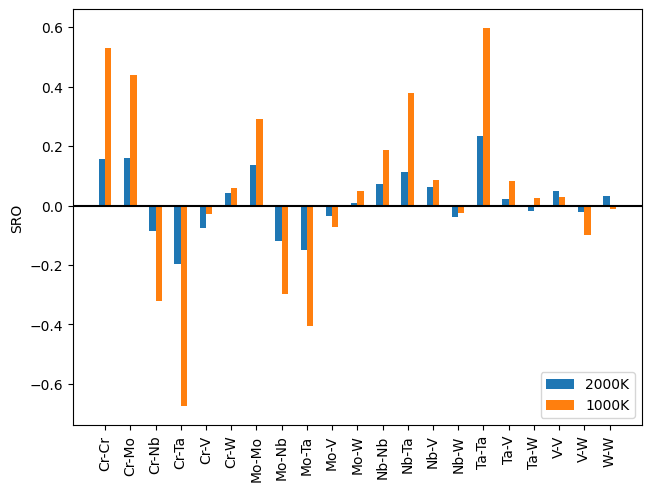

In [22]:
path_to_results = 'results_canonical.json'
# Plot SRO
elements = ['Cr', 'Mo', 'Nb', 'Ta', 'V', 'W']
with open(path_to_results) as f:
    data = json.load(f)
list_pairs = []
list_sro = []
for i, elem1 in enumerate(elements):
    for elem2 in elements[i:]:
        sro = [dct['mean'] for dct in data['SRO_%s-%s_(Orbit_2_0)'%(elem1, elem2)]]
        list_pairs.append('-'.join([elem1, elem2]))
        list_sro.append(sro)
x = np.arange(len(list_pairs))
list_sro = np.array(list_sro).T
width = 0.25
fig, ax = plt.subplots(layout='constrained')
for i, temp in enumerate(data['temperature']):
    offset = width * i
    rects = ax.bar(x + offset, list_sro[i], width, label='%.0fK'%temp)
ax.set_ylabel('SRO')
ax.set_xticks(x + width/2, list_pairs, rotation=90)
ax.legend(loc='lower right', ncols=1)
ax.axhline(0, color='k')

### b) Cool-down simulation

In order to evaluate the entropy, one needs to integrate along a trajectory, for which the entropy of the initial state is known. Typically, within the Canonical ensemble, one perform cool-down simulations. The initial entropy consists of the ideal mixing entropy for the given composition. The free energy is then given by:

The free energy $F = \langle E \rangle - TS$ satisfies the differential equation:

$\frac{\partial (\beta F)}{\partial \beta} = F + \beta \frac{\partial F}{\partial \beta} = F + \frac{1}{k_B \beta} S = \langle E \rangle$

where the $\langle\cdot\rangle$ denotes the ensemble average. The thermodynamic potential is recovered by integrating the differential equation with respect to $\beta$:

$F(\beta, \vec{x}) = \frac{\beta_0}{\beta}F(\beta_0, \vec{x}) + \frac{1}{\beta} \int_{\beta_0} ^ \beta \langle E(b, \vec{x}) \rangle db$

**TASK**

Plot the evolution of the free energy $F$, the enthalpy $H$, and the entropy $S$ as a function of the temperature. The energy per atom as a function of the temperature resulting from a cool-down simulation for the equiatomic senary alloy is given in the file ``Files/cooldown.dat``.

You can use the ``cumulative_simpson`` function to evaluate the integration numerically. You can use $k_B = 8.617333262e-5$.

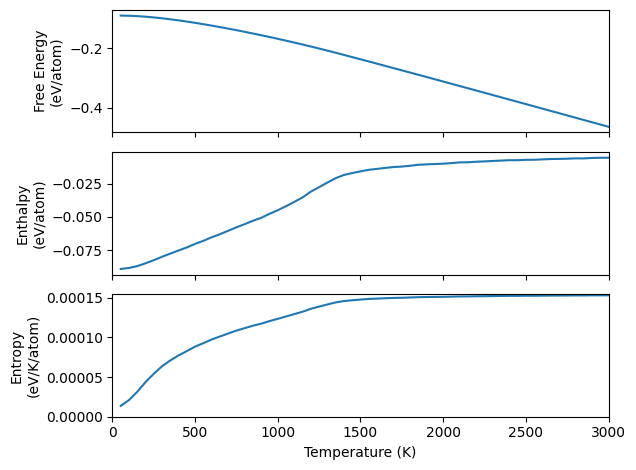

In [23]:
# Parameters
filename = 'Files/cooldown.dat'
kB = 8.617333262e-5
x = np.array([1/6]*6)
Tmax = 3000

# Read results
data = pd.read_csv(filename, sep=' ', skipinitialspace=True)
T = data['temperature_(K)'].to_numpy()
H = data['energy_(eV/atom)'].to_numpy()
beta = 1/(kB*T)

# Initial values
S0 = -kB * (x * np.log(x, out=np.zeros_like(x), where=x > 0)).sum(axis=-1)
F0 = H[0] - T[0] * S0

# Integration
F = (cumulative_simpson(y=H, x=beta, initial=0) + F0 * beta[0]) / beta
S = (H - F) / T

# Plot
fig, ax = plt.subplots(3, 1, sharex=True)
mask = T<= Tmax
for i, (y, ylabel) in enumerate(zip([F, H, S], ['Free Energy\n(eV/atom)', 'Enthalpy\n(eV/atom)', 'Entropy\n(eV/K/atom)'])):
    plt.sca(ax[i])
    plt.plot(T[mask], y[mask])
    plt.ylabel(ylabel)
plt.xlabel('Temperature (K)')
plt.axis([0, Tmax, 0, S0])
plt.tight_layout()
plt.show()